## Librerías

In [ ]:
import re
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from google.colab import files


# knn_demodulation.py
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import LabelEncoder

import time, os


from sklearn.svm import SVC

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline



## Constantes y funciones

### Constantes globales

In [ ]:
QPSK_CONSTELLATION = np.array([
    0.707 + 0.707j,   # 00
   -0.707 + 0.707j,   # 01
   -0.707 - 0.707j,   # 10
    0.707 - 0.707j    # 11
])

ASK4_CONSTELLATION = np.array([
   -3,   # 00
   -1,   # 01
    1,   # 10
    3    # 11
])

# DISTANCES = [0, 2, 20, 40]

### Manipulación de señales y bits

In [ ]:
def sync_signals(tx, rx):
    """
    Sincroniza correlacionando componentes I y Q de forma independiente.
    """
    eps = 1e-9

    # Normalización
    def normalize_signal(s):
        # Separamos componentes para normalizar desvíos de DC y escala de forma independiente
        components = [s.real, s.imag]
        norm_comp = [(c - np.mean(c)) / (np.std(c) + eps) for c in components]
        return norm_comp

    tx_i, tx_q = normalize_signal(tx)
    rx_i, rx_q = normalize_signal(rx)

    # Correlaciones cruzadas (II y QQ)
    corr_ii = np.correlate(rx_i, tx_i, mode="full")
    corr_qq = np.correlate(rx_q, tx_q, mode="full")

    # Suma y detección de retardo (delay)
    total_corr = corr_ii + corr_qq
    delay = np.argmax(total_corr) - (len(tx) - 1)

    # Recorte y alineación
    if delay < 0:
        # El receptor empezó después que el transmisor (o hay pérdida inicial)
        rx_sync = rx[: len(tx) + delay]
        tx_sync = tx[-delay : -delay + len(rx_sync)]
    else:
        # El receptor tiene un retraso positivo
        rx_sync = rx[delay : delay + len(tx)]
        tx_sync = tx[: len(rx_sync)]

    return tx_sync, rx_sync, delay, corr_ii, corr_qq

def plot_constellation(signal, metadata=None, title="Constellation Diagram"):
    """
    Grafica el diagrama de constelación.
    """
    plt.figure(figsize=(6, 7))
    plt.scatter(signal.real, signal.imag, s=1, alpha=0.5, color='royalblue')

    # Estética y ejes
    plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    plt.axvline(0, color='black', linewidth=0.8, alpha=0.5)
    plt.grid(True, linestyle=':', alpha=0.6)

    # Formateo de metadata enfocado en SNR y OSNR
    if metadata:
        # Extraemos valores con un fallback de "N/A" si no existen
        snr = metadata.get('snr_db', 'N/A')
        osnr = metadata.get('osnr_db', 'N/A')
        pwr = metadata.get('launch_power_dbm', 'N/A')
        dist = metadata.get('distance_km', 'N/A')

        full_title = f"{title}\nSNR: {snr} dB | OSNR: {osnr} dB"
        sub_info = f"Power: {pwr} dBm | Distance: {dist} km"

        plt.suptitle(full_title, fontsize=12, fontweight='bold')
        plt.title(sub_info, fontsize=9, color='dimgray')
    else:
        plt.title(title)

    # Ajuste dinámico de límites para evitar distorsión
    limit = np.max(np.abs(signal)) * 1.2 if len(signal) > 0 else 1
    plt.xlim(-limit, limit)
    plt.ylim(-limit, limit)

    plt.xlabel("In-Phase (I)")
    plt.ylabel("Quadrature (Q)")
    plt.gca().set_aspect('equal')
    plt.tight_layout()
    plt.show()

def plot_correlation_results(corr_ii, corr_qq, lags, metadata=None, title="Correlation Analysis"):
    """
    Graficar correlaciones real y compleja.
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # Metadata en el encabezado
    if metadata:
        snr = metadata.get('snr_db', 'N/A')
        osnr = metadata.get('osnr_db', 'N/A')
        fig.suptitle(f"{title}\nSNR: {snr} dB | OSNR: {osnr} dB", fontsize=12, fontweight='bold')

    # Configuración de ejes para I y Q
    plots = [
        (ax1, corr_ii, "I", "dodgerblue"),
        (ax2, corr_qq, "Q", "limegreen")
    ]

    for ax, data, label, color in plots:
        peak_idx = np.argmax(np.abs(data))
        delay = lags[peak_idx]

        ax.plot(lags, data, label=label, color=color, lw=1.2)
        ax.axvline(delay, color='red', ls='--', alpha=0.7, label=f"Peak: {delay}")
        ax.legend(loc='upper right', fontsize='small')
        ax.grid(True, alpha=0.3)

    plt.xlabel("Lag (samples)")
    plt.tight_layout()
    plt.show()

### Modulación y demodulación

In [ ]:
def modulate(bits, constellation):
    """
    Modula bits a símbolos.
    """
    # Determinar bits por símbolo (k) basado en el tamaño de la constelación
    M = len(constellation)
    k = int(np.log2(M))

    # Padding: Asegurar que el flujo de bits sea múltiplo de k
    remainder = len(bits) % k
    if remainder != 0:
        bits = np.append(bits, np.zeros(k - remainder, dtype=int))

    # Agrupar bits y convertir a índices decimales
    # Reshape para tener filas de tamaño 'k'
    reshaped_bits = bits.reshape(-1, k)

    # Convertir cada fila de bits a un índice decimal (MSB primero)
    # [1, 0] -> 1*2^1 + 0*2^0 = 2
    powers = 2**np.arange(k-1, -1, -1)
    indexes = np.dot(reshaped_bits, powers)

    return constellation[indexes]

def demodulate(signal, constellation):
    """
    Demodula buscando el símbolo más cercano (Hard Decision).
    """
    M = len(constellation)
    k = int(np.log2(M))

    # 1. Encontrar el índice del símbolo más cercano en la constelación para cada punto
    distances = np.abs(signal[:, None] - constellation[None, :])
    sym_indices = np.argmin(distances, axis=1)

    # 2. Convertir índices decimales de vuelta a bits
    # Creamos una matriz donde cada fila es la representación binaria del índice
    # Ejemplo para k=2: 0->[0,0], 1->[0,1], 2->[1,0], 3->[1,1]
    bit_map = np.array([[int(b) for b in format(i, f'0{k}b')] for i in range(M)])

    # Extraemos los bits correspondientes a los índices detectados
    bits = bit_map[sym_indices].flatten()

    return bits

In [ ]:
# ─────────────────────────────────────────────
#                    KNN
# ─────────────────────────────────────────────

def find_best_k(rx_sync, tx_sync, constellation=QPSK_CONSTELLATION,
                k_candidates=[1,3,5,7,9,11,15], cv=5, verbose=True):

    X = realify(rx_sync)
    y = symbols_to_labels(tx_sync, constellation)  # ✅ enteros 0-3

    param_grid = {'n_neighbors': k_candidates}
    grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
    grid.fit(X, y)

    best_k = grid.best_params_['n_neighbors']

    if verbose:
        print(f"🔍 GridSearch completado:")
        for k, score in zip(grid.cv_results_['param_n_neighbors'], grid.cv_results_['mean_test_score']):
            print(f"   k={k:>3} → accuracy={score:.4f}")
        print(f"✅ Mejor k: {best_k}  (accuracy={grid.best_score_:.4f})")

    return best_k


def demodulate_knn_kfold(rx_sync, tx_sync, k, constellation=QPSK_CONSTELLATION, n_splits=5):

    X = realify(rx_sync)
    y = symbols_to_labels(tx_sync, constellation)  # ✅ enteros 0-3

    kf = KFold(n_splits=n_splits, shuffle=False)
    ber_per_fold = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # ✅ Convertir índices a bits para calcular BER real
        bits_pred = labels_to_bits(y_pred, constellation)
        bits_true = labels_to_bits(y_test, constellation)

        n = min(len(bits_pred), len(bits_true))
        ber = np.mean(bits_pred[:n] != bits_true[:n])
        ber_per_fold.append(ber)

    ber_arr = np.array(ber_per_fold)

    print(f"📊 KNN (k={k}) — K-Fold (n={n_splits}):")
    for i, ber in enumerate(ber_per_fold):
        print(f"   Fold {i+1}: BER = {ber:.6f}")
    print(f"   → BER medio : {ber_arr.mean():.6f}")
    print(f"   → BER std   : {ber_arr.std():.6f}")

    return {
        'ber_mean':     ber_arr.mean(),
        'ber_std':      ber_arr.std(),
        'ber_per_fold': ber_per_fold,
        'best_k':       k
    }




In [ ]:
# ─────────────────────────────────────────────
#                     SVM
# ─────────────────────────────────────────────

# ─────────────────────────────────────────────
# 1. BÚSQUEDA DE MEJORES C y gamma (GridSearchCV)
# ─────────────────────────────────────────────



def find_best_svm_params(rx_sync, tx_sync, constellation=QPSK_CONSTELLATION,
                          C_candidates=[1, 10], gamma_candidates=['scale'],
                          cv=3, verbose=True,
                          max_symbols=2000):   # ← nuevo parámetro

    X = realify(rx_sync)
    y = symbols_to_labels(tx_sync, constellation)

    # ✅ Subsampleo antes del GridSearch
    if max_symbols is not None and len(X) > max_symbols:
        idx = np.random.choice(len(X), max_symbols, replace=False)
        idx = np.sort(idx)
        X, y = X[idx], y[idx]

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    param_grid = {'C': C_candidates, 'gamma': gamma_candidates}
    grid = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=cv,
                        scoring='accuracy', n_jobs=-1)
    grid.fit(X, y)

    best_C     = grid.best_params_['C']
    best_gamma = grid.best_params_['gamma']

    if verbose:
        print(f"🔍 GridSearch SVM completado:")
        print(f"   Mejor C     : {best_C}")
        print(f"   Mejor gamma : {best_gamma}")
        print(f"   Accuracy    : {grid.best_score_:.4f}")

    return best_C, best_gamma

# ─────────────────────────────────────────────
# 2. DEMODULACIÓN SVM CON K-FOLD
# ─────────────────────────────────────────────

def demodulate_svm_kfold(rx_sync, tx_sync, C, gamma,
                          constellation=QPSK_CONSTELLATION,
                          n_splits=5,
                          max_symbols=2000):   # ← nuevo parámetro

    X = realify(rx_sync)
    y = symbols_to_labels(tx_sync, constellation)

    # ✅ Subsampleo aleatorio para acelerar el entrenamiento
    if max_symbols is not None and len(X) > max_symbols:
        idx = np.random.choice(len(X), max_symbols, replace=False)
        idx = np.sort(idx)   # mantener orden temporal
        X, y = X[idx], y[idx]

    kf = KFold(n_splits=n_splits, shuffle=False)
    ber_per_fold = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

        model = SVC(kernel='rbf', C=C, gamma=gamma)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        bits_pred = labels_to_bits(y_pred, constellation)
        bits_true = labels_to_bits(y_test, constellation)

        n = min(len(bits_pred), len(bits_true))
        ber = np.mean(bits_pred[:n] != bits_true[:n])
        ber_per_fold.append(ber)

    ber_arr = np.array(ber_per_fold)

    print(f"📊 SVM (C={C}, gamma={gamma}) — K-Fold (n={n_splits}) — símbolos={len(X)}:")
    for i, ber in enumerate(ber_per_fold):
        print(f"   Fold {i+1}: BER = {ber:.6f}")
    print(f"   → BER medio : {ber_arr.mean():.6f}")
    print(f"   → BER std   : {ber_arr.std():.6f}")

    return {
        'ber_mean':     ber_arr.mean(),
        'ber_std':      ber_arr.std(),
        'ber_per_fold': ber_per_fold,
        'best_C':       C,
        'best_gamma':   gamma
    }


### Utilidades

In [ ]:
def realify(signal: np.ndarray) -> np.ndarray:
    """Convierte señal compleja a matriz 2D [I, Q] para sklearn."""
    return np.column_stack([signal.real, signal.imag])

In [ ]:
def symbols_to_labels(tx_sync: np.ndarray, constellation: np.ndarray) -> np.ndarray:
    """
    Convierte símbolos TX complejos a índices enteros 0,1,2,3
    buscando el símbolo más cercano en la constelación.
    """
    # Para cada símbolo TX, encontrar el índice en la constelación
    distances = np.abs(tx_sync[:, None] - constellation[None, :])
    return np.argmin(distances, axis=1)   # → array de enteros [0, 1, 2, 3]


def labels_to_bits(labels: np.ndarray, constellation: np.ndarray) -> np.ndarray:
    """
    Convierte índices 0-3 de vuelta a bits usando el mapeo de la constelación.
    Ejemplo: 0→[0,0], 1→[0,1], 2→[1,0], 3→[1,1]
    """
    M = len(constellation)
    k = int(np.log2(M))
    bit_map = np.array([[int(b) for b in format(i, f'0{k}b')] for i in range(M)])
    return bit_map[labels].flatten()

In [ ]:
def extract_value(pattern, text, conversion_func=float):
    """
    Función interna genérica para buscar un patrón en el texto.
    """
    # Buscar el patrón ignorando mayúsculas/minúsculas
    match = re.search(pattern, text, re.IGNORECASE)
    if match:
        value_str = match.group(1)
        # Reemplazar la 'p' por punto decimal para poder convertir a float
        if 'p' in value_str:
            value_str = value_str.replace('p', '.')
        return conversion_func(value_str)
    return None

def get_launch_power(filename):
    # Busca potencia en dBm (soporta negativos, ej: -3dBm o 0p5dBm)
    return extract_value(r"([-+]?\d+(?:p\d+)?)dbm", filename)

def get_distance(filename):
    return extract_value(r"(\d+(?:p\d+)?)km", filename)

def get_osnr(filename):
    return extract_value(r"osnr(\d+p\d+)db", filename)

def get_snr(filename):
    return extract_value(r"(?<!o)snr(\d+p\d+)db", filename)

def get_carrier_freq(filename):
    return extract_value(r"(\d+)mhz", filename, int)

def get_bitrate(filename):
    return extract_value(r"(\d+)mbps", filename, int)

def parse_filename_metadata(filename):
    """
    Extrae todos los parámetros y los devuelve en un diccionario.
    """
    metadata = {
        "launch_power_dbm": get_launch_power(filename),
        "distance_km":      get_distance(filename),
        "osnr_db":          get_osnr(filename),
        "snr_db":           get_snr(filename),
        "freq_mhz":         get_carrier_freq(filename),
        "bitrate_mbps":     get_bitrate(filename)
    }
    return metadata

def load_results(output_filename):
    # Intentar cargar la base de datos existente
    if os.path.exists(output_filename):
        results_df = pd.read_csv(output_filename)
        # Usamos un set de los nombres de archivos ya procesados para una búsqueda rápida
        processed_files = set(results_df['filename'].unique())
        # Convertimos el dataframe a lista de diccionarios para seguir añadiendo
        results_list = results_df.to_dict('records')
        print(f"✅ Base de datos cargada: {len(results_list)} registros previos.")
    else:
        results_list = []
        processed_files = set()
        print("❌ No hay resultados previos. Se creará una nueva base de datos.")
    return results_list, processed_files

## Proceso principal

In [ ]:
def main_pipeline(rx_paths, processed_files, results_list, output_filename, max_files=None):
    start_time = time.time()

    for path in rx_paths:
        if not os.path.exists(path):
            print(f"⚠️ Saltando {path}: archivo no encontrado.")
            continue

        current_npz = np.load(path, allow_pickle=True)
        all_files = current_npz.files

        files_to_process = [f for f in all_files if f not in processed_files]
        skipped = len(all_files) - len(files_to_process)

        # ✅ Limitar archivos si se pasa max_files
        if max_files is not None:
            files_to_process = files_to_process[:max_files]

        print(f"\n📂 NPZ: {path}")
        if skipped > 0:
            print(f"⏩ Saltando {skipped} archivos ya procesados...")

        pbar = tqdm(files_to_process, desc=f"Procesando {path}", unit="file")

        for name in pbar:
            metadata = parse_filename_metadata(name.lower())
            rx_signal = current_npz[name]
            rotation_results = []

            # Actualizamos el texto de la barra con el OSNR actual (opcional)
            pbar.set_postfix(OSNR=metadata.get('osnr_db', '?'))

            for rot in [1, 1j, -1, -1j]:
                rx_rotated = rx_signal * rot

                # Sincronización y alineación
                tx_s, rx_s, delay, _, _ = sync_signals(tx_ref, rx_rotated)

                # Demodulación y cálculo de BER
                b_ref = demodulate(tx_s, QPSK_CONSTELLATION)
                b_rx  = demodulate(rx_s, QPSK_CONSTELLATION)

                n = min(len(b_ref), len(b_rx))
                if n == 0: continue

                ber = np.mean(b_ref[:n] != b_rx[:n])
                rotation_results.append({'ber': ber, 'delay': delay})

            if rotation_results:
                best_case = min(rotation_results, key=lambda x: x['ber'])
                metadata.update({
                    'filename': name,
                    'ber': best_case['ber'],
                    'detected_delay': best_case['delay'],
                    'npz_source': path
                })
                results_list.append(metadata)
                processed_files.add(name)





        # Guardado intermedio por cada NPZ terminado
        pd.DataFrame(results_list).to_csv(output_filename, index=False)
        print(f"✅ Progreso guardado. Total en BD: {len(results_list)}")
        files.download(output_filename)

    total_duration = time.time() - start_time
    print(f"\n✨ Pipeline finalizado en {total_duration:.2f} segundos.")

In [ ]:
# ─────────────────────────────────────────────
# 3. PIPELINE KNN COMPLETO
# ─────────────────────────────────────────────

def knn_pipeline(
    rx_paths: list,
    tx_ref: np.ndarray,
    sync_fn,
    parse_fn,
    output_filename: str,
    k_candidates: list = [1, 3, 5, 7, 9, 11, 15],
    n_splits: int = 5,
    max_files: int = None
):
    """
    Pipeline completo KNN sobre archivos NPZ.
    Genera el mismo CSV que el método tradicional + columna 'method'='knn'.

    Parameters
    ----------
    rx_paths : list
        Lista de rutas a archivos .npz (igual que main_pipeline).
    tx_ref : np.ndarray
        Señal de referencia TX (compleja).
    sync_fn : callable
        Función de sincronización (sync_signals).
    parse_fn : callable
        Función de parseo de metadata (parse_filename_metadata).
    output_filename : str
        Ruta del CSV de salida.
    k_candidates : list
        Valores de k para GridSearch.
    n_splits : int
        Folds para K-Fold final.
    max_files : int, optional
        Limita archivos por NPZ (para pruebas rápidas).
    """

    results_list, processed_files = load_results(output_filename)
    start_time = time.time()

    for path in rx_paths:
        if not os.path.exists(path):
            print(f"⚠️  Saltando {path}: no encontrado.")
            continue

        current_npz = np.load(path, allow_pickle=True)
        files_to_process = list(current_npz.files)

        # ✅ Saltar archivos ya procesados (igual que el tradicional)
        files_to_process = [f for f in files_to_process if f not in processed_files]

        if max_files is not None:
            files_to_process = files_to_process[:max_files]

        print(f"\n📂 NPZ: {path}  ({len(files_to_process)} archivos)")

        for name in files_to_process:
            print(f"\n  📡 {name}")
            metadata = parse_fn(name.lower())
            rx_signal = current_npz[name]

            best_ber   = np.inf
            best_k_global = None

            # Probar las 4 rotaciones de fase (igual que el tradicional)
            for rot in [1, 1j, -1, -1j]:
                rx_rotated = rx_signal * rot

                # Sincronización TX↔RX
                tx_s, rx_s, delay, _, _ = sync_fn(tx_ref, rx_rotated)
                if len(tx_s) == 0 or len(rx_s) == 0:
                    continue

                # ── GridSearch para encontrar mejor k ──
                best_k = find_best_k(
                    rx_s, tx_s,
                    k_candidates=k_candidates,
                    cv=min(3, n_splits),   # 3 folds en GridSearch para velocidad
                    verbose=False
                )

                # ── K-Fold con el mejor k ──
                knn_results = demodulate_knn_kfold(
                    rx_s, tx_s,
                    k=best_k,
                    n_splits=n_splits
                )

                if knn_results['ber_mean'] < best_ber:
                    best_ber      = knn_results['ber_mean']
                    best_k_global = best_k

            metadata.update({
                'filename':      name,
                'ber':           best_ber,
                'best_k':        best_k_global,
                'method':        'knn',
                'npz_source':    path
            })
            results_list.append(metadata)
            print(f"  ✔ BER={best_ber:.6f}  k={best_k_global}")

    # Guardar CSV
    df = pd.DataFrame(results_list)
    df.to_csv(output_filename, index=False)
    print(f"\n✨ Pipeline KNN finalizado en {time.time()-start_time:.2f}s")
    print(f"💾 Guardado en: {output_filename}")

    return df

In [ ]:
# ─────────────────────────────────────────────
# 3. PIPELINE SVM COMPLETO
# ─────────────────────────────────────────────

"""
    rx_paths: list,
    tx_ref: np.ndarray,
    sync_fn,
    parse_fn,
    output_filename: str,
    C_candidates: list = [0.1, 1, 10, 100],
    gamma_candidates: list = [0.01, 0.1, 1, 'scale'],
    n_splits: int = 5,
    max_files: int = None


"""

def svm_pipeline(
    rx_paths: list,
    tx_ref: np.ndarray,
    sync_fn,
    parse_fn,
    output_filename: str,
    C_candidates    = [1, 10],        # ← solo 2 valores en vez de 4
    gamma_candidates = ['scale'],     # ← solo 1 valor en vez de 4
    n_splits        = 3,              # ← 3 folds en vez de 5
    max_files       = None               # ← solo 1 archivo en vez de 3
):
    """
    Pipeline completo SVM sobre archivos NPZ.
    Genera el mismo CSV que main_pipeline y knn_pipeline.
    """
    import time, os

    results_list, processed_files = load_results(output_filename)
    start_time = time.time()

    for path in rx_paths:
        if not os.path.exists(path):
            print(f"⚠️  Saltando {path}: no encontrado.")
            continue

        current_npz = np.load(path, allow_pickle=True)
        files_to_process = [f for f in current_npz.files if f not in processed_files]

        if max_files is not None:
            files_to_process = files_to_process[:max_files]

        print(f"\n📂 NPZ: {path}  ({len(files_to_process)} archivos)")

        for name in files_to_process:
            print(f"\n  📡 {name}")
            metadata    = parse_fn(name.lower())
            rx_signal   = current_npz[name]

            best_ber       = np.inf
            best_C_global     = None
            best_gamma_global = None

            for rot in [1, 1j, -1, -1j]:
                rx_rotated = rx_signal * rot
                tx_s, rx_s, delay, _, _ = sync_fn(tx_ref, rx_rotated)
                if len(tx_s) == 0 or len(rx_s) == 0:
                    continue

                # GridSearch → mejores C y gamma
                best_C, best_gamma = find_best_svm_params(
                    rx_s, tx_s,
                    C_candidates=C_candidates,
                    gamma_candidates=gamma_candidates,
                    cv=min(3, n_splits),
                    verbose=False
                )

                # K-Fold con los mejores parámetros
                svm_results = demodulate_svm_kfold(
                    rx_s, tx_s,
                    C=best_C,
                    gamma=best_gamma,
                    n_splits=n_splits
                )

                if svm_results['ber_mean'] < best_ber:
                    best_ber          = svm_results['ber_mean']
                    best_C_global     = best_C
                    best_gamma_global = best_gamma

            metadata.update({
                'filename':   name,
                'ber':        best_ber,
                'best_C':     best_C_global,
                'best_gamma': best_gamma_global,
                'method':     'svm',
                'npz_source': path
            })
            results_list.append(metadata)
            processed_files.add(name)
            print(f"  ✔ BER={best_ber:.6f}  C={best_C_global}  gamma={best_gamma_global}")

        # Guardado intermedio por NPZ
        pd.DataFrame(results_list).to_csv(output_filename, index=False)
        print(f"✅ Progreso guardado. Total en BD: {len(results_list)}")

    print(f"\n✨ Pipeline SVM finalizado en {time.time()-start_time:.2f}s")
    print(f"💾 Guardado en: {output_filename}")

    return pd.DataFrame(results_list)

### Cargar datos

In [ ]:
# Bits transmitidos (TX)
!gdown 1RXSmwwvAFrpuyjo6c7dU_lzNQmnJ80d5

# DFB (usando pasos de 1 dB)
# 0 km
# !gdown 1ERpfPPJqVCY3gV9Vxo4svllCwcyrIjzX
# # 2 km
# !gdown 1QRH4PaurMJRMW2gApy397tgAaNtPr1mA
# # 20 km
# !gdown 1wG_3o6nLCNEbYS0vhqqAYwu5cWXX7DHu
# # 40 km
# !gdown 1eOyne5EZ_WBe0zEzV1iYwHGWm7_qZM9r

# DFB (usando pasos de 0.4 dB)
# 0 km
!gdown 1rhLsooKt0OV0lrZVP1Tv2R3XzUR28Pa7
# 2 km
!gdown 1D2BV7jwCBB-Q5ngGfRHyGz87j68BXqBI
# 20 km
!gdown 1JSDd5HQYzCRjtUSnkKGZ10jrZi9aGpK7
# 40 km
!gdown 19rMA29ybHCWq4aYP1kteFCLPbA3NnxN5

# USPL (usando pasos de 1 dB)
# 0 km
!gdown 1Z9zuD-_BBi3R3kbk7paI15zlBOBQJkPG
# 20 km
!gdown 1zbjHAsjdIR_ZF05XvrPxVN3hG5I5ie4D

# Resultados
# DFB (usando pasos de 1 dB)
!gdown 19JF1TEHVNC4lDzKaHGdE6ki5wGvYF8aC
# DFB (usando pasos de 0.4 dB)
!gdown 19B_Y1dTr2U4_wrj9rUmiOZJopkWTBR7r
# USPL
!gdown 1KxWEcLxSasC5oK2UcHISLPjfEjdaPPdC

Downloading...
From: https://drive.google.com/uc?id=1RXSmwwvAFrpuyjo6c7dU_lzNQmnJ80d5
To: /content/tx.txt
100% 131k/131k [00:00<00:00, 95.4MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1rhLsooKt0OV0lrZVP1Tv2R3XzUR28Pa7
From (redirected): https://drive.google.com/uc?id=1rhLsooKt0OV0lrZVP1Tv2R3XzUR28Pa7&confirm=t&uuid=f68948b9-e859-4e53-b2d9-a15757b02a33
To: /content/rof_dfb_0dBm_0km_650mhz_1p88mbps.npz
100% 380M/380M [00:06<00:00, 55.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1D2BV7jwCBB-Q5ngGfRHyGz87j68BXqBI
From (redirected): https://drive.google.com/uc?id=1D2BV7jwCBB-Q5ngGfRHyGz87j68BXqBI&confirm=t&uuid=87f85b53-9435-419d-b93d-a88c66afddde
To: /content/rof_dfb_0dBm_2km_650mhz_1p88mbps.npz
100% 332M/332M [00:01<00:00, 200MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1JSDd5HQYzCRjtUSnkKGZ10jrZi9aGpK7
From (redirected): https://drive.google.com/uc?id=1JSDd5HQYzCRjtUSnkKGZ10jrZi9aGpK7&confirm=t&uuid=881f94bb-dce4-4d

In [ ]:
# Ruta al archivo de bits
TX_PATH = "tx.txt"

with open(TX_PATH, "r") as f:
    bitstring1 = f.read().strip()

print("Cantidad de bits:", len(bitstring1))
print("Primeros 50 bits:", bitstring1[:50])

bits_tx = np.array([int(b) for b in bitstring1], dtype=np.uint8)

# Referencia de transmisión
tx_ref = modulate(bits_tx, QPSK_CONSTELLATION)

Cantidad de bits: 131072
Primeros 50 bits: 00000101010101010001011111111110110101000000010000


## DFB

In [ ]:
# WARN: Usamos datos antiguos porque los nuevos tardan demasiado en procesar
POWER = "0"
FREQ = "650"
#DATA_RATE = "2"
DATA_RATE = "1p88"
LASER_TYPE = "dfb"
DISTANCES = [0, 2, 20, 40]

#rx_paths_dfb = [f"rof_{POWER}dBm_{d}km_{FREQ}mhz_{DATA_RATE}mbps.npz" for d in DISTANCES]
rx_paths_dfb = [f"rof_{LASER_TYPE}_{POWER}dBm_{d}km_{FREQ}mhz_{DATA_RATE}mbps.npz" for d in DISTANCES]

data0, data2, data20, data40 = 0, 0, 0, 0
data_dfb = [data0, data2, data20, data40]

for datum, path in zip(data_dfb, rx_paths_dfb):
  datum = np.load(path, allow_pickle=True)
  print(f"📂 Datos de {path} cargados con {len(datum)} archivos")

📂 Datos de rof_dfb_0dBm_0km_650mhz_1p88mbps.npz cargados con 160 archivos
📂 Datos de rof_dfb_0dBm_2km_650mhz_1p88mbps.npz cargados con 140 archivos
📂 Datos de rof_dfb_0dBm_20km_650mhz_1p88mbps.npz cargados con 70 archivos
📂 Datos de rof_dfb_0dBm_40km_650mhz_1p88mbps.npz cargados con 100 archivos


### Evaluar hard decision

In [ ]:
#output_filename_dfb = f"results_qpsk_{LASER_TYPE}.csv"
output_filename_dfb = f"results_qpsk_prueba2_{LASER_TYPE}_extended.csv"
results_list_dfb, processed_files_dfb = load_results(output_filename_dfb)

✅ Base de datos cargada: 12 registros previos.


In [ ]:

# SE AGREGO EL MAXFILES PARA PRUEBAS CORTAS.

#main_pipeline(rx_paths_dfb, processed_files_dfb, results_list_dfb, output_filename_dfb)
main_pipeline(rx_paths_dfb, processed_files_dfb, results_list_dfb, output_filename_dfb, max_files=3)

### Evaluar KNN

In [ ]:
output_filename_knn_dfb = f"results_knn_prueba1_{LASER_TYPE}_extended.csv"
# results_list_knn_dfb, processed_files_knn_dfb = load_results(output_filename_knn_dfb)  -> no va porque ya no va. Ahora load_results se llama dentro de knn_pipeline automáticamente,
# así que esa línea sería redundante.

In [ ]:
# SE AGREGO EL MAXFILES PARA PRUEBAS CORTAS.
knn_pipeline(rx_paths_dfb, tx_ref, sync_signals, parse_filename_metadata, output_filename_knn_dfb, max_files=3)

❌ No hay resultados previos. Se creará una nueva base de datos.

📂 NPZ: rof_dfb_0dBm_0km_650mhz_1p88mbps.npz  (3 archivos)

  📡 rof_0dBm_0km_osnr32p40dB_650mhz_1p88mbps_snr3p11dB
📊 KNN (k=11) — K-Fold (n=5):
   Fold 1: BER = 0.506828
   Fold 2: BER = 0.497864
   Fold 3: BER = 0.497253
   Fold 4: BER = 0.496986
   Fold 5: BER = 0.501335
   → BER medio : 0.500053
   → BER std   : 0.003730
📊 KNN (k=9) — K-Fold (n=5):
   Fold 1: BER = 0.501030
   Fold 2: BER = 0.501068
   Fold 3: BER = 0.498894
   Fold 4: BER = 0.493820
   Fold 5: BER = 0.499237
   → BER medio : 0.498810
   → BER std   : 0.002650
📊 KNN (k=1) — K-Fold (n=5):
   Fold 1: BER = 0.502556
   Fold 2: BER = 0.498894
   Fold 3: BER = 0.497215
   Fold 4: BER = 0.496376
   Fold 5: BER = 0.499771
   → BER medio : 0.498962
   → BER std   : 0.002159
📊 KNN (k=15) — K-Fold (n=5):
   Fold 1: BER = 0.498665
   Fold 2: BER = 0.497597
   Fold 3: BER = 0.497253
   Fold 4: BER = 0.498779
   Fold 5: BER = 0.503014
   → BER medio : 0.499062
   → 

,launch_power_dbm,distance_km,osnr_db,snr_db,freq_mhz,bitrate_mbps,filename,ber,best_k,method,npz_source
0,0.0,0.0,32.4,3.11,650,88,rof_0dBm_0km_osnr32p40dB_650mhz_1p88mbps_snr3p...,0.498810,9,knn,rof_dfb_0dBm_0km_650mhz_1p88mbps.npz
1,0.0,0.0,32.4,3.16,650,88,rof_0dBm_0km_osnr32p40dB_650mhz_1p88mbps_snr3p...,0.497971,1,knn,rof_dfb_0dBm_0km_650mhz_1p88mbps.npz
2,0.0,0.0,32.4,3.17,650,88,rof_0dBm_0km_osnr32p40dB_650mhz_1p88mbps_snr3p...,0.496521,15,knn,rof_dfb_0dBm_0km_650mhz_1p88mbps.npz
3,0.0,2.0,33.2,NaN,650,88,rof_0dBm_2km_osnr33p20dB_650mhz_1p88mbps_snr-8...,0.498695,15,knn,rof_dfb_0dBm_2km_650mhz_1p88mbps.npz
4,0.0,2.0,33.2,4.58,650,88,rof_0dBm_2km_osnr33p20dB_650mhz_1p88mbps_snr4p...,0.461349,15,knn,rof_dfb_0dBm_2km_650mhz_1p88mbps.npz
5,0.0,2.0,33.2,4.63,650,88,rof_0dBm_2km_osnr33p20dB_650mhz_1p88mbps_snr4p...,0.498344,15,knn,rof_dfb_0dBm_2km_650mhz_1p88mbps.npz
6,0.0,20.0,36.0,5.58,650,88,rof_0dBm_20km_osnr36p00dB_650mhz_1p88mbps_snr5...,0.480171,15,knn,rof_dfb_0dBm_20km_650mhz_1p88mbps.npz
7,0.0,20.0,36.0,5.91,650,88,rof_0dBm_20km_osnr36p00dB_650mhz_1p88mbps_snr5...,0.479682,15,knn,rof_dfb_0dBm_20km_650mhz_1p88mbps.npz
8,0.0,20.0,36.0,5.92,650,88,rof_0dBm_20km_osnr36p00dB_650mhz_1p88mbps_snr5...,0.433335,15,knn,rof_dfb_0dBm_20km_650mhz_1p88mbps.npz
9,0.0,40.0,34.8,6.18,650,88,rof_0dBm_40km_osnr34p80dB_650mhz_1p88mbps_snr6...,0.436697,15,knn,rof_dfb_0dBm_40km_650mhz_1p88mbps.npz


### Evaluar SVM

In [ ]:
output_filename_svm_dfb = f"results_svm_prueba1_{LASER_TYPE}_extended.csv"

# SE AGREGO EL MAXFILES PARA PRUEBAS CORTAS.
#svm_pipeline(rx_paths_dfb, tx_ref, sync_signals, parse_filename_metadata, output_filename_svm_dfb)
svm_pipeline(rx_paths_dfb, tx_ref, sync_signals, parse_filename_metadata, output_filename_svm_dfb, max_files=3)

❌ No hay resultados previos. Se creará una nueva base de datos.

📂 NPZ: rof_dfb_0dBm_0km_650mhz_1p88mbps.npz  (3 archivos)

  📡 rof_0dBm_0km_osnr32p40dB_650mhz_1p88mbps_snr3p11dB
📊 SVM (C=1, gamma=scale) — K-Fold (n=3) — símbolos=2000:
   Fold 1: BER = 0.494003
   Fold 2: BER = 0.473763
   Fold 3: BER = 0.491742
   → BER medio : 0.486503
   → BER std   : 0.009055
📊 SVM (C=1, gamma=scale) — K-Fold (n=3) — símbolos=2000:
   Fold 1: BER = 0.502249
   Fold 2: BER = 0.510495
   Fold 3: BER = 0.503754
   → BER medio : 0.505499
   → BER std   : 0.003585
📊 SVM (C=1, gamma=scale) — K-Fold (n=3) — símbolos=2000:
   Fold 1: BER = 0.486507
   Fold 2: BER = 0.502999
   Fold 3: BER = 0.496997
   → BER medio : 0.495501
   → BER std   : 0.006815
📊 SVM (C=10, gamma=scale) — K-Fold (n=3) — símbolos=2000:
   Fold 1: BER = 0.500750
   Fold 2: BER = 0.504498
   Fold 3: BER = 0.494745
   → BER medio : 0.499997
   → BER std   : 0.004017
  ✔ BER=0.486503  C=1  gamma=scale

  📡 rof_0dBm_0km_osnr32p40dB_650mhz_

,launch_power_dbm,distance_km,osnr_db,snr_db,freq_mhz,bitrate_mbps,filename,ber,best_C,best_gamma,method,npz_source
0,0.0,0.0,32.4,3.11,650,88,rof_0dBm_0km_osnr32p40dB_650mhz_1p88mbps_snr3p...,0.486503,1,scale,svm,rof_dfb_0dBm_0km_650mhz_1p88mbps.npz
1,0.0,0.0,32.4,3.16,650,88,rof_0dBm_0km_osnr32p40dB_650mhz_1p88mbps_snr3p...,0.489245,10,scale,svm,rof_dfb_0dBm_0km_650mhz_1p88mbps.npz
2,0.0,0.0,32.4,3.17,650,88,rof_0dBm_0km_osnr32p40dB_650mhz_1p88mbps_snr3p...,0.479005,10,scale,svm,rof_dfb_0dBm_0km_650mhz_1p88mbps.npz
3,0.0,2.0,33.2,NaN,650,88,rof_0dBm_2km_osnr33p20dB_650mhz_1p88mbps_snr-8...,0.497251,10,scale,svm,rof_dfb_0dBm_2km_650mhz_1p88mbps.npz
4,0.0,2.0,33.2,4.58,650,88,rof_0dBm_2km_osnr33p20dB_650mhz_1p88mbps_snr4p...,0.476511,1,scale,svm,rof_dfb_0dBm_2km_650mhz_1p88mbps.npz
5,0.0,2.0,33.2,4.63,650,88,rof_0dBm_2km_osnr33p20dB_650mhz_1p88mbps_snr4p...,0.505002,10,scale,svm,rof_dfb_0dBm_2km_650mhz_1p88mbps.npz
6,0.0,20.0,36.0,5.58,650,88,rof_0dBm_20km_osnr36p00dB_650mhz_1p88mbps_snr5...,0.442244,1,scale,svm,rof_dfb_0dBm_20km_650mhz_1p88mbps.npz
7,0.0,20.0,36.0,5.91,650,88,rof_0dBm_20km_osnr36p00dB_650mhz_1p88mbps_snr5...,0.459496,1,scale,svm,rof_dfb_0dBm_20km_650mhz_1p88mbps.npz
8,0.0,20.0,36.0,5.92,650,88,rof_0dBm_20km_osnr36p00dB_650mhz_1p88mbps_snr5...,0.404021,10,scale,svm,rof_dfb_0dBm_20km_650mhz_1p88mbps.npz
9,0.0,40.0,34.8,6.18,650,88,rof_0dBm_40km_osnr34p80dB_650mhz_1p88mbps_snr6...,0.425005,1,scale,svm,rof_dfb_0dBm_40km_650mhz_1p88mbps.npz


### Gráficas

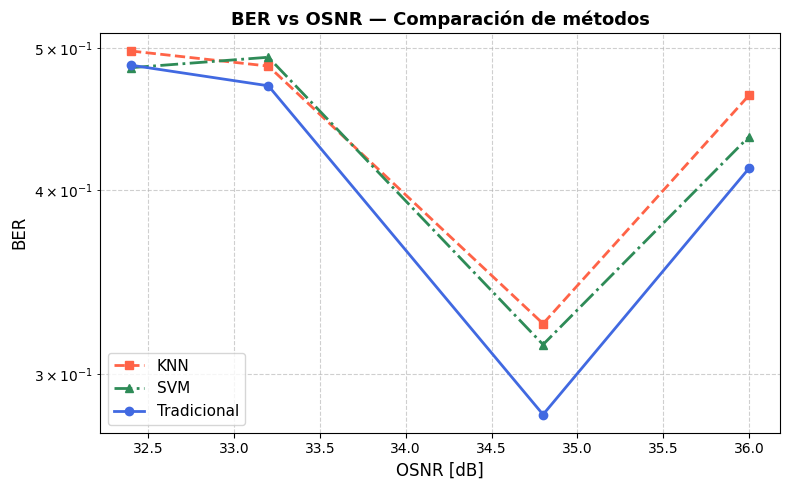

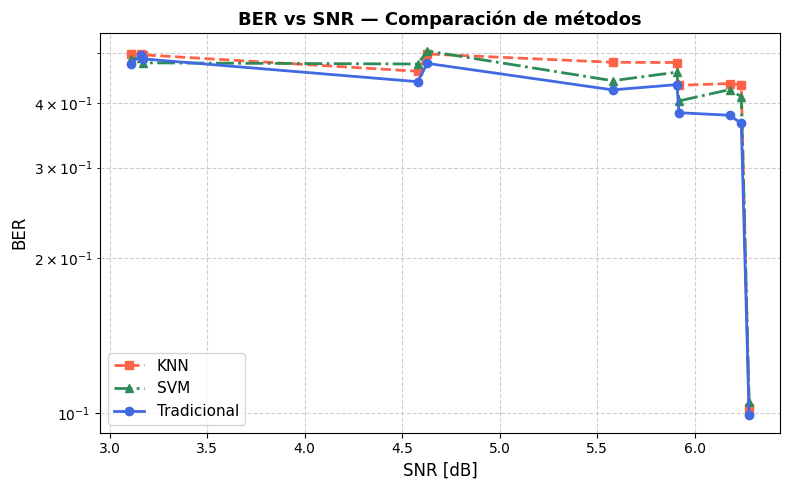

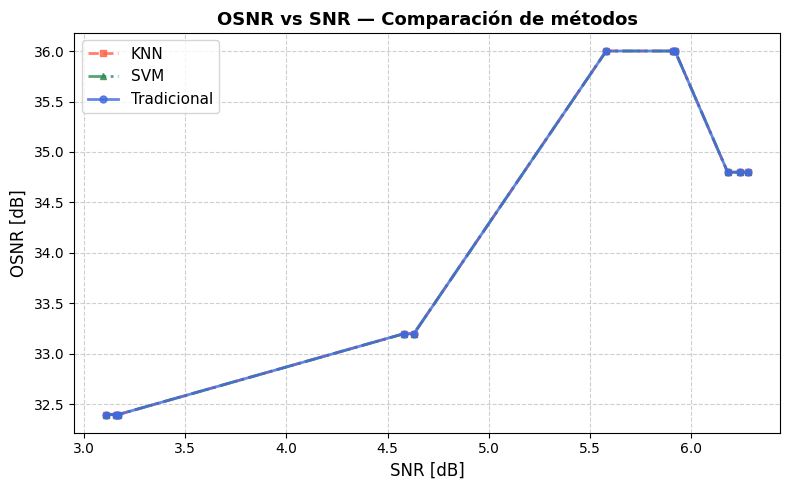

In [ ]:


# ─────────────────────────────────────────────
# CARGA DE DATOS
# ─────────────────────────────────────────────

df_trad = pd.read_csv("results_qpsk_prueba1_dfb_extended.csv").assign(method='Tradicional')
df_knn  = pd.read_csv("results_knn_prueba1_dfb_extended.csv").assign(method='KNN')
df_svm  = pd.read_csv("results_svm_prueba1_dfb_extended.csv").assign(method='SVM')

df_all = pd.concat([df_trad, df_knn, df_svm], ignore_index=True)

# Configuración visual por método
STYLE = {
    'Tradicional': {'color': 'royalblue',  'marker': 'o', 'ls': '-'},
    'KNN':         {'color': 'tomato',     'marker': 's', 'ls': '--'},
    'SVM':         {'color': 'seagreen',   'marker': '^', 'ls': '-.'},
}

# ─────────────────────────────────────────────
# FUNCIÓN AUXILIAR: agrupar y promediar
# ─────────────────────────────────────────────

def get_mean_curve(df, x_col, y_col):
    """Agrupa por x_col, promedia y_col y devuelve arrays ordenados."""
    grouped = df.groupby(x_col)[y_col].mean().reset_index()
    grouped = grouped.sort_values(x_col)
    return grouped[x_col].values, grouped[y_col].values


# ─────────────────────────────────────────────
# GRÁFICA 1 — BER vs OSNR
# ─────────────────────────────────────────────

fig1, ax1 = plt.subplots(figsize=(8, 5))

for method, df in df_all.groupby('method'):
    s = STYLE[method]
    x, y = get_mean_curve(df, 'osnr_db', 'ber')
    # Filtrar BER = 0 para evitar problemas con log
    mask = y > 0
    ax1.semilogy(x[mask], y[mask],
                 color=s['color'], marker=s['marker'], ls=s['ls'],
                 linewidth=2, markersize=6, label=method)

ax1.set_xlabel("OSNR [dB]", fontsize=12)
ax1.set_ylabel("BER", fontsize=12)
ax1.set_title("BER vs OSNR — Comparación de métodos", fontsize=13, fontweight='bold')
ax1.grid(True, which='both', linestyle='--', alpha=0.6)
ax1.legend(fontsize=11)
plt.tight_layout()
plt.savefig("ber_vs_osnr_comparacion.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 2 — BER vs SNR
# ─────────────────────────────────────────────

fig2, ax2 = plt.subplots(figsize=(8, 5))

for method, df in df_all.groupby('method'):
    s = STYLE[method]
    x, y = get_mean_curve(df, 'snr_db', 'ber')
    mask = y > 0
    ax2.semilogy(x[mask], y[mask],
                 color=s['color'], marker=s['marker'], ls=s['ls'],
                 linewidth=2, markersize=6, label=method)

ax2.set_xlabel("SNR [dB]", fontsize=12)
ax2.set_ylabel("BER", fontsize=12)
ax2.set_title("BER vs SNR — Comparación de métodos", fontsize=13, fontweight='bold')
ax2.grid(True, which='both', linestyle='--', alpha=0.6)
ax2.legend(fontsize=11)
plt.tight_layout()
plt.savefig("ber_vs_snr_comparacion.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 3 — OSNR vs SNR
# ─────────────────────────────────────────────
# Esta gráfica es independiente del método (es una propiedad del canal),
# pero la graficamos por método para ver si hay diferencias en los datos.

fig3, ax3 = plt.subplots(figsize=(8, 5))

for method, df in df_all.groupby('method'):
    s = STYLE[method]
    # Eliminar NaN
    df_clean = df[['osnr_db', 'snr_db']].dropna().sort_values('snr_db')
    ax3.plot(df_clean['snr_db'], df_clean['osnr_db'],
             color=s['color'], marker=s['marker'], ls=s['ls'],
             linewidth=2, markersize=5, alpha=0.8, label=method)

ax3.set_xlabel("SNR [dB]", fontsize=12)
ax3.set_ylabel("OSNR [dB]", fontsize=12)
ax3.set_title("OSNR vs SNR — Comparación de métodos", fontsize=13, fontweight='bold')
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.legend(fontsize=11)
plt.tight_layout()
plt.savefig("osnr_vs_snr_comparacion.png", dpi=150)
plt.show()

## USPL

In [ ]:
POWER = "-3"
FREQ = "650"
DATA_RATE = "1p88"
LASER_TYPE = "uspl"
DISTANCES = [0, 20]
rx_paths_uspl = [f"rof_{LASER_TYPE}_{POWER}dBm_{d}km_{FREQ}mhz_{DATA_RATE}mbps.npz" for d in DISTANCES]

data0, data20 = 0, 0
data_uspl = [data0, data20]

for datum, path in zip(data_uspl, rx_paths_uspl):
  datum = np.load(path, allow_pickle=True)
  print(f"📂 Datos de {path} cargados con {len(datum)} archivos")

📂 Datos de rof_uspl_-3dBm_0km_650mhz_1p88mbps.npz cargados con 55 archivos
📂 Datos de rof_uspl_-3dBm_20km_650mhz_1p88mbps.npz cargados con 50 archivos


### Evaluar

In [ ]:
output_filename_uspl = f"results_qpsk_{LASER_TYPE}.csv"
results_list_uspl, processed_files_uspl = load_results(output_filename_uspl)

✅ Base de datos cargada: 105 registros previos.


In [ ]:
main_pipeline(rx_paths_uspl, processed_files_uspl, results_list_uspl, output_filename_uspl)


📂 NPZ: rof_uspl_-3dBm_0km_650mhz_1p88mbps.npz
⏩ Saltando 55 archivos ya procesados...


Procesando rof_uspl_-3dBm_0km_650mhz_1p88mbps.npz: 0file [00:00, ?file/s]

✅ Progreso guardado. Total en BD: 105


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

Procesando rof_uspl_-3dBm_20km_650mhz_1p88mbps.npz: 0file [00:00, ?file/s]

✅ Progreso guardado. Total en BD: 105


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✨ Pipeline finalizado en 0.09 segundos.


# TODO: MOVE TO ANOTHER NOTEBOOK

# Código fundador

In [ ]:
from collections import defaultdict

ber_osnr = defaultdict(list)

tx_ref = bits_to_qpsk(bits_tx)

for name in datos.files:

    osnr = extraer_osnr(name)
    if osnr is None:
        continue

    data = datos[name]
    resultados = []

    # ===== TU BLOQUE FUNCIONAL (SIN CAMBIOS) =====
    for k, rot in enumerate([1, 1j, -1, -1j]):
        rx_rot = data * rot
        tx_s, rx_s, _, corr_i, corr_q = sync_by_components(tx_ref, rx_rot)

        b_ref = demodular_qpsk(tx_s)
        b_rx  = demodular_qpsk(rx_s)

        n = min(len(b_ref), len(b_rx))
        # HOLA HANNA, ACÁ TAMBIÉN SE ESTÁ RECORTANDO, PERO SI ARREGLAS LA DE
        # ARRIBA ESTA YA NO HACE DAÑO Y LA PUEDES DEJAR ;D
        ber = np.mean(b_ref[:n] != b_rx[:n])

        resultados.append({'ber': ber})
    # ============================================

    mejor = min(resultados, key=lambda x: x['ber'])
    ber_osnr[osnr].append(mejor['ber'])


NameError: name 'bits_to_qpsk' is not defined

In [ ]:
osnr_vals = sorted(ber_osnr.keys())
ber_mean = [np.mean(ber_osnr[o]) for o in osnr_vals]

plt.figure(figsize=(7,5))
plt.semilogy(osnr_vals, ber_mean, 'o-')
plt.grid(True, which='both')
plt.xlabel("OSNR (dB)")
plt.ylabel("BER")
plt.title("BER vs OSNR (QPSK)")
plt.show()


## BER vs SNR

In [ ]:
from collections import defaultdict
import matplotlib.pyplot as plt

ber_snr = defaultdict(list)

tx_ref = bits_to_qpsk(bits_tx)

for name in datos.files:

    snr = extraer_snr(name)
    if snr is None:
        continue

    data = datos[name]
    resultados = []

    # ===== TU BLOQUE FUNCIONAL (SIN CAMBIOS) =====
    for k, rot in enumerate([1, 1j, -1, -1j]):

        rx_rot = data * rot
        tx_s, rx_s, _, _, _ = sync_by_components(tx_ref, rx_rot)

        b_ref = demodular_qpsk(tx_s)
        b_rx  = demodular_qpsk(rx_s)

        n = min(len(b_ref), len(b_rx))
        ber = np.mean(b_ref[:n] != b_rx[:n])

        resultados.append({'ber': ber})
    # ============================================

    mejor = min(resultados, key=lambda x: x['ber'])
    ber_snr[snr].append(mejor['ber'])


In [ ]:
snr_vals = sorted(ber_snr.keys())
ber_mean = [np.mean(ber_snr[s]) for s in snr_vals]

plt.figure(figsize=(7,5))
plt.semilogy(snr_vals, ber_mean, 'o-')
plt.grid(True, which='both')
plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.title("BER vs SNR (QPSK)")
plt.show()

In [ ]:
snr_vals = np.array(sorted(ber_snr.keys()))
ber_vals = np.array([np.mean(ber_snr[k]) for k in snr_vals])

ber_smooth = moving_average(ber_vals, window=10)


In [ ]:
plt.figure(figsize=(7,5))

plt.semilogy(snr_vals, ber_vals, 'o-', alpha=0.4, label="BER original")
plt.semilogy(snr_vals, ber_smooth, '-r', linewidth=2, label="BER suavizada")

plt.grid(True, which='both')
plt.xlabel("SNR / SMR (dB)")
plt.ylabel("BER")
plt.title("BER vs SNR (Media móvil)")
plt.legend()
plt.show()

In [ ]:
#BER vs OSNR para 2 km

ber_osnr = defaultdict(list)

tx_ref = bits_to_qpsk(bits_tx1)

for name in datos1.files:

    osnr = extraer_osnr(name)
    if osnr is None:
        continue

    data = datos1[name]
    resultados = []

    # ===== TU BLOQUE FUNCIONAL (SIN CAMBIOS) =====
    for k, rot in enumerate([1, 1j, -1, -1j]):
        rx_rot = data * rot
        tx_s, rx_s, _, corr_i, corr_q = sync_by_components(tx_ref, rx_rot)

        b_ref = demodular_qpsk(tx_s)
        b_rx  = demodular_qpsk(rx_s)

        n = min(len(b_ref), len(b_rx))
        # HOLA HANNA, ACÁ TAMBIÉN SE ESTÁ RECORTANDO, PERO SI ARREGLAS LA DE
        # ARRIBA ESTA YA NO HACE DAÑO Y LA PUEDES DEJAR ;D
        ber = np.mean(b_ref[:n] != b_rx[:n])

        resultados.append({'ber': ber})
    # ============================================

    mejor = min(resultados, key=lambda x: x['ber'])
    ber_osnr[osnr].append(mejor['ber'])

## Depuración

In [ ]:
#versión corregida de la función para tratar con los archivos de 2km:
def sync_by_components1(tx_ideal, rx_long):
    """
    Sincroniza correlacionando I y Q de forma independiente y sumando sus contribuciones.
    """
    eps = 1e-9  # <-- EPSILON para evitar colapso numérico

    # 1. Normalización ROBUSTA
    tx_i = (tx_ideal.real - np.mean(tx_ideal.real)) / (np.std(tx_ideal.real) + eps)
    tx_q = (tx_ideal.imag - np.mean(tx_ideal.imag)) / (np.std(tx_ideal.imag) + eps)

    rx_i = (rx_long.real - np.mean(rx_long.real)) / (np.std(rx_long.real) + eps)
    rx_q = (rx_long.imag - np.mean(rx_long.imag)) / (np.std(rx_long.imag) + eps)

    # 2. Correlaciones cruzadas independientes
    corr_ii = np.correlate(rx_i, tx_i, mode="full")
    corr_qq = np.correlate(rx_q, tx_q, mode="full")

    # 3. Suma de correlaciones
    total_corr = corr_ii + corr_qq

    lags = np.arange(-len(tx_ideal) + 1, len(rx_long))
    delay = lags[np.argmax(total_corr)]

    # 4. Recorte (igual que antes)
    if delay < 0:
        rx_sync = rx_long[0 : len(tx_ideal) + delay]
        tx_sync = tx_ideal[-delay : -delay + len(rx_sync)]
    else:
        rx_sync = rx_long[delay : delay + len(tx_ideal)]
        tx_sync = tx_ideal[:len(rx_sync)]

    return tx_sync, rx_sync, delay, corr_ii, corr_qq

name = "rof_0dBm_0km_osnrXdB_650mhz_1mbps_snrXdB.bin"
data = np.fromfile(name, dtype=np.complex64)
resultados = []
tx_ref = bits_to_qpsk(bits_tx1)

print(f"Analizando {name} con sincronización por fase...")

for k, rot in enumerate([1, 1j, -1, -1j]):
    fase_label = k * 90

    # Aplicamos la rotación a toda la señal antes de sincronizar
    rx_rot = data * rot
    #print("data dtype:", data.dtype)
    # Sincronizamos buscando el pico en la parte REAL para esta rotación
    tx_s, rx_s, delay, corr_i, corr_q = sync_by_components1(tx_ref, rx_rot)

    #print(f'tx_s:',tx_s[:5], f'rx_s:', rx_s[:5])

    # Demodulamos y calculamos BER
    b_ref = demodular_qpsk(tx_s)
    b_rx = demodular_qpsk(rx_s)

    n = min(len(b_ref), len(b_rx))
    ber = np.mean(b_ref[:n] != b_rx[:n])

    # Guardamos los datos para comparar
    resultados.append({
        'rot': fase_label,
        'ber': ber,
        'delay': delay,
        'sig': rx_s,
        'corr_plot': corr_i + corr_q
    })

    print(f" > Fase {fase_label}°: BER = {ber:.6f} | Pico Real detectado en lag {delay}")

# --- ELECCIÓN DEL MEJOR RESULTADO ---
mejor = min(resultados, key=lambda x: x['ber'])

# Visualización de la correlación que dio el mejor BER
plt.figure(figsize=(10, 4))
plt.plot(mejor['corr_plot'])
plt.title(f"Mejor Correlación Real (Fase {mejor['rot']}°)")
plt.grid(True)
plt.show()

# Constelación final
plot_constellation(mejor['sig'], title=f"Resultado: {mejor['rot']}° | BER: {mejor['ber']:.5f}")


In [ ]:
name = "coax_1mbps_650mhz_snrXdB.bin"
data = np.fromfile(name, dtype=np.complex64)
tx_ref = bits_to_qpsk(bits_tx1)

In [ ]:
def sync_by_components(tx_ideal, rx_long):
    """
    Sincroniza correlacionando I y Q de forma independiente y sumando sus contribuciones.
    """
    eps = 1e-9  # <-- EPSILON para evitar colapso numérico

    # 1. Normalización ROBUSTA
    tx_i = (tx_ideal.real - np.mean(tx_ideal.real)) / (np.std(tx_ideal.real) + eps)
    tx_q = (tx_ideal.imag - np.mean(tx_ideal.imag)) / (np.std(tx_ideal.imag) + eps)

    rx_i = (rx_long.real - np.mean(rx_long.real)) / (np.std(rx_long.real) + eps)
    rx_q = (rx_long.imag - np.mean(rx_long.imag)) / (np.std(rx_long.imag) + eps)

    # 2. Correlaciones cruzadas independientes
    corr_ii = np.correlate(rx_i, tx_i, mode="full")
    corr_qq = np.correlate(rx_q, tx_q, mode="full")

    # 3. Suma de correlaciones
    total_corr = corr_ii + corr_qq

    lags = np.arange(-len(tx_ideal) + 1, len(rx_long))
    delay = lags[np.argmax(total_corr)]

    # 4. Recorte (igual que antes)
    if delay < 0:
        rx_sync = rx_long[0 : len(tx_ideal) + delay]
        tx_sync = tx_ideal[-delay : -delay + len(rx_sync)]
    else:
        rx_sync = rx_long[delay : delay + len(tx_ideal)]
        tx_sync = tx_ideal[:len(rx_sync)]

    return tx_sync, rx_sync, delay, corr_ii, corr_qq
# --- PARÁMETROS ---
#name = datos1.files[35]
#name = "rof_2km_1mbps_650mhz_osnr35p72dB_snr8p57dB"
#name = "rof_2km_1mbps_650mhz_osnr35p72dB_snr8p83dB"
#name = "rof_2km_1mbps_650mhz_osnr35p72dB_snr9p09dB"
#name = "rof_2km_1mbps_650mhz_osnr35p72dB_snr9p50dB"
#name = "rof_2km_1mbps_650mhz_osnr35p72dB_snr9p61dB"
print(name)
#print(f'data:', data[:5])
tx_ref = bits_to_qpsk(bits_tx1)
resultados = []

print(f"Analizando {name} con sincronización por fase...")

for k, rot in enumerate([1, 1j, -1, -1j]):
    fase_label = k * 90

    # Aplicamos la rotación a toda la señal antes de sincronizar
    rx_rot = data * rot
    #print("data dtype:", data.dtype)
    # Sincronizamos buscando el pico en la parte REAL para esta rotación
    tx_s, rx_s, delay, corr_i, corr_q = sync_by_components1(tx_ref, rx_rot)

    #print(f'tx_s:',tx_s[:5], f'rx_s:', rx_s[:5])

    # Demodulamos y calculamos BER
    b_ref = demodular_qpsk(tx_s)
    b_rx = demodular_qpsk(rx_s)

    n = min(len(b_ref), len(b_rx))
    ber = np.mean(b_ref[:n] != b_rx[:n])

    # Guardamos los datos para comparar
    resultados.append({
        'rot': fase_label,
        'ber': ber,
        'delay': delay,
        'sig': rx_s,
        'corr_plot': corr_i + corr_q
    })

    print(f" > Fase {fase_label}°: BER = {ber:.6f} | Pico Real detectado en lag {delay}")

# --- ELECCIÓN DEL MEJOR RESULTADO ---
mejor = min(resultados, key=lambda x: x['ber'])

# Visualización de la correlación que dio el mejor BER
plt.figure(figsize=(10, 4))
plt.plot(mejor['corr_plot'])
plt.title(f"Mejor Correlación Real (Fase {mejor['rot']}°)")
plt.grid(True)
plt.show()

# Constelación final
plot_constellation(mejor['sig'], title=f"Resultado: {mejor['rot']}° | BER: {mejor['ber']:.5f}")

In [ ]:
#CÓDIGO FINAL
tx_ref = bits_to_qpsk(bits_tx1)

resultados_globales = []

for idx, name in enumerate(datos2.files):
    data = datos2[name]
    resultados = []

    print(f"\nAnalizando archivo {idx} → {name} con sincronización por fase...")

    for k, rot in enumerate([1, 1j, -1, -1j]):
        fase_label = k * 90

        # Rotación de fase
        rx_rot = data * rot

        # Sincronización
        tx_s, rx_s, delay, corr_i, corr_q = sync_by_components1(
            tx_ref, rx_rot
        )

        # Demodulación
        b_ref = demodular_qpsk(tx_s)
        b_rx  = demodular_qpsk(rx_s)

        n = min(len(b_ref), len(b_rx))
        ber = np.mean(b_ref[:n] != b_rx[:n])

        resultados.append({
            'archivo': name,
            'rot': fase_label,
            'ber': ber,
            'delay': delay,
            'sig': rx_s,
            'corr_plot': corr_i + corr_q
        })

        print(f"  > Fase {fase_label}°: BER = {ber:.6e} | Delay = {delay}")

    # --- Mejor resultado por archivo ---
    mejor = min(resultados, key=lambda x: x['ber'])
    resultados_globales.append(mejor)

    print(
        f" ✔ Mejor fase para {name}: "
        f"{mejor['rot']}° | BER = {mejor['ber']:.6e}"
    )


In [ ]:
print(resultados_globales)

In [ ]:
ber_por_osnr = defaultdict(list)

for r in resultados_globales:
    osnr = extraer_osnr(r['archivo'])
    if osnr is not None:
        ber_por_osnr[osnr].append(float(r['ber']))

osnr_vals = np.array(sorted(ber_por_osnr.keys()))
ber_mean  = np.array([np.mean(ber_por_osnr[o]) for o in osnr_vals])
ber_std   = np.array([np.std(ber_por_osnr[o])  for o in osnr_vals])  # opcional


plt.figure(figsize=(7, 5))
plt.semilogy(osnr_vals, ber_mean, 'o-', linewidth=2, label='BER promedio')

plt.xlabel("OSNR [dB]")
plt.ylabel("BER")
plt.title("BER vs OSNR (promediado)")

plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
MAX_SYMBOLS = 20_000
segmento_rx = data[:MAX_SYMBOLS]
autocorr = np.correlate(segmento_rx, np.conj(segmento_rx), mode='full')
mag_autocorr = np.abs(autocorr)

plt.figure(figsize=(12, 4))
plt.plot(mag_autocorr)
plt.title("Autocorrelación de la Señal Recibida")
plt.show()